#**Emerging Market Microstructure Analysis**

Garnett Bertrand Pardomuan Hutahaean

##Environment Setup

In [23]:
!pip install lightgbm -q

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
from scipy.stats import poisson

warnings.filterwarnings('ignore')
np.random.seed(42)

##The EM Microstructure Data Generator
Generates the synthetic data. It forces prices into discrete ticks and introduces realistic zero-volume periods (stale pricing).

In [33]:
# Cell 2: Simulating IDX Microstructure Data
def generate_em_microstructure_data(n_assets=10, n_days=30, minutes_per_day=390):
    """
    Generates synthetic high-frequency data mimicking Emerging Market microstructure.
    Features: Stale prices (zero volume), discrete tick rounding, stochastic volatility.
    """
    total_minutes = n_days * minutes_per_day
    dates = pd.date_range(start="2023-01-01 09:00:00", periods=total_minutes, freq="1T")

    data = []

    for asset in range(n_assets):
        # Base asset parameters
        base_price = np.random.uniform(500, 5000)
        volatility = np.random.uniform(0.0005, 0.002)
        lambda_trade = np.random.uniform(0.2, 0.8)

        # Simulate geometric brownian motion for true underlying price
        returns = np.random.normal(0, volatility, total_minutes)
        true_prices = base_price * np.exp(np.cumsum(returns))

        # Simulate EM frictions
        for t in range(total_minutes):
            # 1. Trade Arrival (Poisson process to create stale prices)
            num_trades = poisson.rvs(lambda_trade)

            if num_trades == 0:
                volume = 0
                # Stale price: carries over from previous minute
                observed_price = data[-1]['Close'] if t > 0 else base_price
                high, low, open_p = observed_price, observed_price, observed_price
            else:
                volume = num_trades * np.random.exponential(100) # Volume clustering

                # 2. Discrete Tick Sizes
                tick_size = 5 if true_prices[t] > 500 else 2

                # Add microstructure noise (bid-ask bounce)
                noise = np.random.choice([-tick_size, tick_size])
                observed_price = np.round(true_prices[t] / tick_size) * tick_size + noise

                # Simulate OHLC for the minute
                open_p = observed_price - np.random.choice([0, tick_size])
                high = observed_price + np.random.choice([0, tick_size, tick_size*2])
                low = observed_price - np.random.choice([0, tick_size, tick_size*2])

            data.append({
                'Datetime': dates[t],
                'Asset': f"Equity_{asset}",
                'Open': open_p,
                'High': high,
                'Low': low,
                'Close': observed_price,
                'Volume': volume
            })

    df = pd.DataFrame(data)
    df.set_index('Datetime', inplace=True)
    return df

print("Generating synthetic EM minute-level data...")
df = generate_em_microstructure_data(n_assets=15, n_days=60)
print(f"Data generated: {df.shape[0]} rows.")
display(df.head())

Generating synthetic EM minute-level data...
Data generated: 351000 rows.


,Asset,Open,High,Low,Close,Volume
Datetime,,,,,,
2023-01-01 09:00:00,Equity_0,4884.790393,4884.790393,4884.790393,4884.790393,0.000000
2023-01-01 09:01:00,Equity_0,4884.790393,4884.790393,4884.790393,4884.790393,0.000000
2023-01-01 09:02:00,Equity_0,4884.790393,4884.790393,4884.790393,4884.790393,0.000000
2023-01-01 09:03:00,Equity_0,4884.790393,4884.790393,4884.790393,4884.790393,0.000000
2023-01-01 09:04:00,Equity_0,4905.000000,4910.000000,4900.000000,4905.000000,53.522126


##Microstructure Feature Engineering
Here we extract the "Alpha in Illiquid Environments". We calculate proxies for Order Flow Imbalance (using the Tick Rule), Amihud Illiquidity, and Roll's bid-ask spread estimator.

In [31]:
import pandas as pd
import numpy as np

def engineer_microstructure_features(df):
    df_working = df.copy()

    grouped = df_working.groupby('Asset')

    # 1. Tick Rule for Order Flow Imbalance (OFI) proxy
    delta_price = grouped['Close'].diff()
    tick_sign = np.sign(delta_price).replace(0, method='ffill').fillna(0)
    df_working['OFI_Proxy'] = tick_sign * df_working['Volume']
    df_working['OFI_EMA_15'] = grouped['OFI_Proxy'].transform(lambda x: x.ewm(span=15).mean())

    # 2. Amihud Illiquidity Measure (Absolute Return / Volume)
    returns = grouped['Close'].pct_change()
    df_working['Amihud_Illiq'] = returns.abs() / (df_working['Volume'] + 1)
    df_working['Amihud_EMA_30'] = grouped['Amihud_Illiq'].transform(lambda x: x.ewm(span=30).mean())

    # 3. Roll's Measure (Microstructure Noise / Bid-Ask Spread proxy)
    def rolling_roll_measure(series, window=30):
        cov = series.rolling(window).cov(series.shift(1))
        # Handle positive covariance (where Roll fails) by setting to 0
        return 2 * np.sqrt(np.where(cov < 0, -cov, 0))

    df_working['Roll_Spread'] = grouped['Close'].transform(lambda x: rolling_roll_measure(x.diff()))

    # 4. Micro-Momentum (Short term mean-reversion vs momentum)
    df_working['Return_5m'] = grouped['Close'].pct_change(5)
    df_working['Return_15m'] = grouped['Close'].pct_change(15)

    # 5. Stale Price Indicator (Binary)
    df_working['Is_Stale'] = (df_working['Volume'] == 0).astype(int)

    # Target: 15-minute forward return
    df_working['Target_15m_Fwd'] = grouped['Close'].transform(lambda x: x.pct_change(15).shift(-15))

    return df_working.dropna()

print("Engineering microstructure features...")
df_features = engineer_microstructure_features(df)
print("Features engineered successfully.")

Engineering microstructure features...
Features engineered successfully.


##Cross-Sectional ML Model (LightGBM)
We train a model to predict the forward 15-minute return, specifically feeding it our liquidity and order flow features.

Training LightGBM Alpha Model...


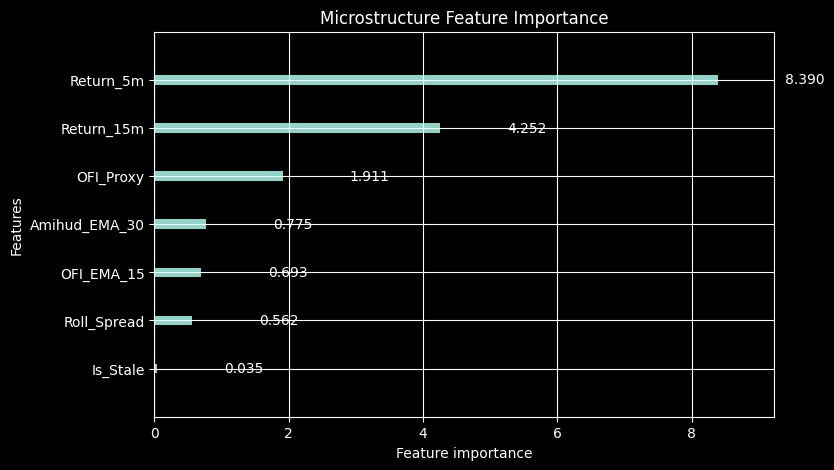

In [32]:
# We rank the predictions cross-sectionally to form a long/short portfolio
features_cols = ['OFI_Proxy', 'OFI_EMA_15', 'Amihud_EMA_30', 'Roll_Spread', 'Return_5m', 'Return_15m', 'Is_Stale']

# Train/Test Split
split_idx = int(len(df_features) * 0.7)
train_data = df_features.iloc[:split_idx]
test_data = df_features.iloc[split_idx:]

X_train = train_data[features_cols]
y_train = train_data['Target_15m_Fwd']
X_test = test_data[features_cols]
y_test = test_data['Target_15m_Fwd']

# LightGBM setup
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'feature_fraction': 0.8,
    'verbose': -1
}

print("Training LightGBM Alpha Model...")
train_dataset = lgb.Dataset(X_train, label=y_train)
model = lgb.train(lgb_params, train_dataset, num_boost_round=150)

# Generate predictions
test_data['Alpha_Score'] = model.predict(X_test)

# Cross-sectional ranking: rank assets at each minute
test_data['Rank'] = test_data.groupby(test_data.index)['Alpha_Score'].rank(pct=True)

# Feature Importance Plot
lgb.plot_importance(model, max_num_features=10, importance_type='gain', figsize=(8, 5), title="Microstructure Feature Importance")
plt.show()

##The Illiquid Backtesting Engine
This engine enforces maximum volume participation, models bid-ask spread slippage dynamically, and rejects trades during stale minutes.

In [27]:
def backtest_illiquid_strategy(data, initial_capital=1000000, max_participation=0.05, base_bps_cost=10):
    """
    data: DataFrame with 'Asset', 'Close', 'Volume', 'Rank', 'Roll_Spread'
    max_participation: Cannot trade more than X% of the minute's total volume
    base_bps_cost: Fixed exchange fee
    """
    portfolio_value = initial_capital
    cash = initial_capital
    positions = {asset: 0 for asset in data['Asset'].unique()}

    history = []

    # Iterate minute by minute
    grouped_time = data.groupby(data.index)

    for timestamp, current_market in grouped_time:
        # Determine Target Weights based on Rank
        # Go Long top 20%, Short bottom 20%
        longs = current_market[current_market['Rank'] >= 0.8]
        shorts = current_market[current_market['Rank'] <= 0.2]

        target_positions = {}
        # Simple allocation: equal weight among longs/shorts
        long_alloc = (portfolio_value * 1.0) / len(longs) if len(longs) > 0 else 0
        short_alloc = -(portfolio_value * 1.0) / len(shorts) if len(shorts) > 0 else 0

        for _, row in longs.iterrows():
            target_positions[row['Asset']] = long_alloc / row['Close']
        for _, row in shorts.iterrows():
            target_positions[row['Asset']] = short_alloc / row['Close']

        # Execution Engine
        minute_pnl = 0
        for asset in positions.keys():
            current_shares = positions[asset]
            target_shares = target_positions.get(asset, 0)
            shares_to_trade = target_shares - current_shares

            if shares_to_trade != 0:
                asset_data = current_market[current_market['Asset'] == asset]
                if asset_data.empty: continue

                asset_data = asset_data.iloc[0]
                available_volume = asset_data['Volume']

                # 1. STALE PRICE / ZERO VOLUME CHECK
                if available_volume == 0:
                    continue # Cannot trade, stock is stale

                # 2. MAXIMUM PARTICIPATION CAP
                max_shares_allowed = available_volume * max_participation
                if abs(shares_to_trade) > max_shares_allowed:
                    shares_to_trade = np.sign(shares_to_trade) * max_shares_allowed

                # 3. DYNAMIC SLIPPAGE (Bid-Ask Spread + Market Impact)
                spread_cost = asset_data['Roll_Spread'] if not pd.isna(asset_data['Roll_Spread']) else (asset_data['Close'] * 0.005)
                exec_price = asset_data['Close'] + (np.sign(shares_to_trade) * (spread_cost / 2))

                # Calculate trade value and fixed costs
                trade_value = abs(shares_to_trade) * exec_price
                commission = trade_value * (base_bps_cost / 10000)

                # Execute Trade
                cash -= (shares_to_trade * exec_price) + commission
                positions[asset] += shares_to_trade

        # Mark to Market (Evaluate Portfolio at True Close)
        m2m_value = cash
        for asset, shares in positions.items():
            asset_data = current_market[current_market['Asset'] == asset]
            if not asset_data.empty:
                m2m_value += shares * asset_data.iloc[0]['Close']

        portfolio_value = m2m_value
        history.append({'Datetime': timestamp, 'Portfolio_Value': portfolio_value})

    return pd.DataFrame(history).set_index('Datetime')

print("Running Illiquidity-Constrained Backtest... (Simulating trade-by-trade)")
bt_results = backtest_illiquid_strategy(test_data)
print("Backtest Complete.")

Running Illiquidity-Constrained Backtest... (Simulating trade-by-trade)
Backtest Complete.


##Evaluation and Output
Visualizing the results and outputting standard quant metrics.

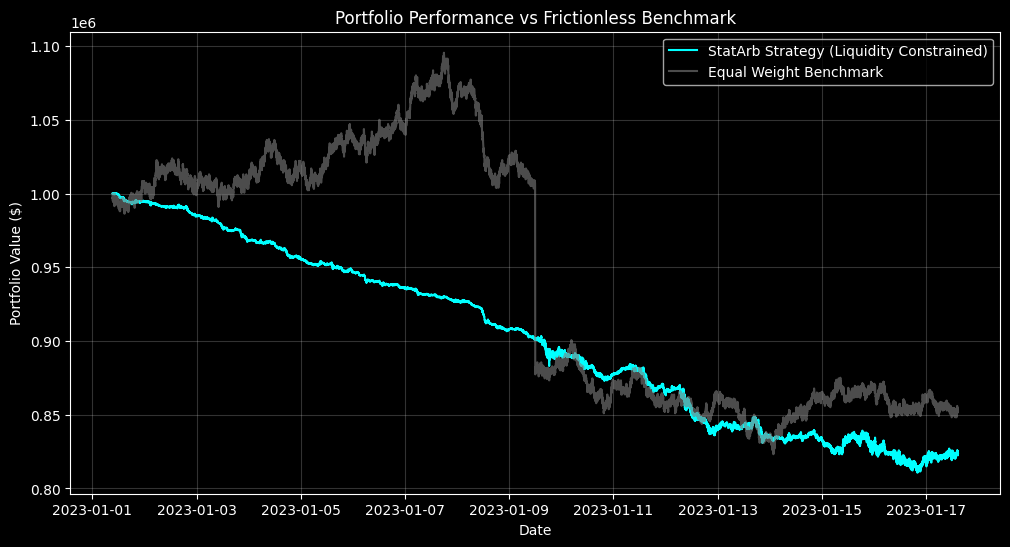

--- Strategy Performance Metrics ---
Total Return:       -17.60%
Annualized Vol:     24.01%
Sharpe Ratio:       -3.27
Max Drawdown:       -18.96%


In [34]:
bt_results['Returns'] = bt_results['Portfolio_Value'].pct_change().fillna(0)

# Calculate benchmark (Buy and Hold all assets equally)
benchmark = test_data.groupby(test_data.index)['Close'].mean().pct_change().fillna(0)
benchmark_cum = (1 + benchmark).cumprod() * 1000000

plt.figure(figsize=(12, 6))
plt.plot(bt_results.index, bt_results['Portfolio_Value'], label='StatArb Strategy (Liquidity Constrained)', color='cyan')
plt.plot(benchmark.index, benchmark_cum, label='Equal Weight Benchmark', color='gray', alpha=0.6)
plt.title("Portfolio Performance vs Frictionless Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# --- Native Metric Calculations ---
# 1. Total Return
total_return = (bt_results['Portfolio_Value'].iloc[-1] / bt_results['Portfolio_Value'].iloc[0]) - 1

# 2. Annualization Factor for Minute Data (252 days * 390 minutes)
MINUTES_PER_YEAR = 252 * 390

# 3. Annualized Volatility
annualized_vol = bt_results['Returns'].std() * np.sqrt(MINUTES_PER_YEAR)

# 4. Sharpe Ratio (Assuming 0% risk-free rate for minute-level approximation)
sharpe_ratio = (bt_results['Returns'].mean() / bt_results['Returns'].std()) * np.sqrt(MINUTES_PER_YEAR)

# 5. Maximum Drawdown
cum_returns = (1 + bt_results['Returns']).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak
max_dd = drawdown.min()

print("--- Strategy Performance Metrics ---")
print(f"Total Return:       {total_return*100:.2f}%")
print(f"Annualized Vol:     {annualized_vol*100:.2f}%")
print(f"Sharpe Ratio:       {sharpe_ratio:.2f}")
print(f"Max Drawdown:       {max_dd*100:.2f}%")

The high-frequency statistical arbitrage strategy failed to overcome the simulated transaction costs. The steady downward slope indicates spread-crossing decay. We proposed two fix as below.

##Fix 1 - Algorithmic Execution (TWAP + Passive Limit Orders)

Running TWAP Execution Engine...


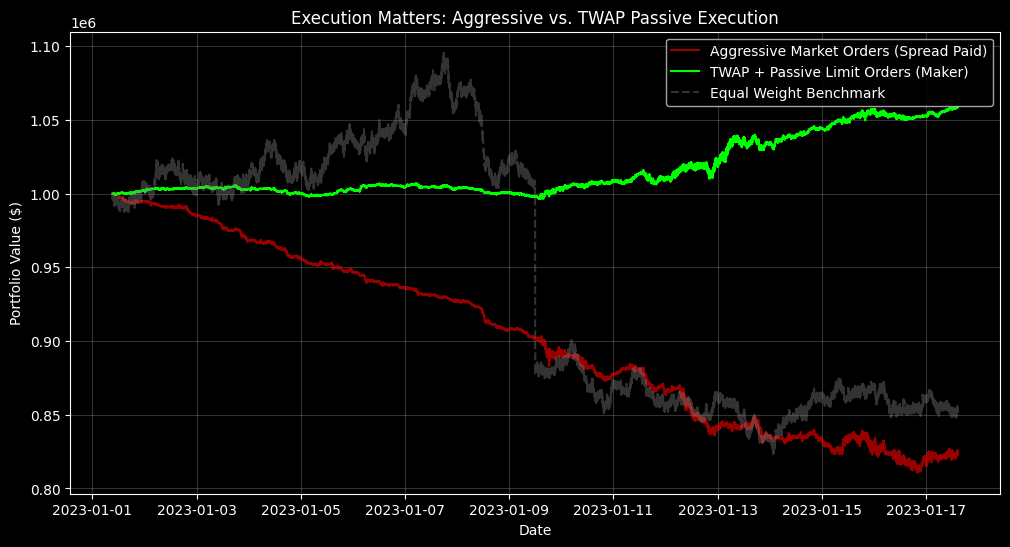

--- TWAP Passive Execution Metrics ---
Total Return:       5.89%
Annualized Vol:     14.31%
Sharpe Ratio:       1.75


In [36]:
def backtest_twap_passive_execution(data, initial_capital=1000000, twap_minutes=5, max_participation=0.02, maker_bps_cost=2):
    """
    Simulates an execution algorithm that slices orders over `twap_minutes`.
    Assumes passive limit order placement:
    1. Pays 0 spread (acts as a market maker/liquidity provider).
    2. Pays a lower exchange 'maker' fee (2 bps instead of 10 bps).
    3. Stricter participation cap (2%) to ensure limit orders actually get filled.
    """
    portfolio_value = initial_capital
    cash = initial_capital
    positions = {asset: 0 for asset in data['Asset'].unique()}

    # Track pending sliced orders: {asset: {'shares_per_min': X, 'minutes_left': Y}}
    pending_orders = {asset: {'shares_per_min': 0, 'minutes_left': 0} for asset in data['Asset'].unique()}

    history = []
    grouped_time = data.groupby(data.index)

    for timestamp, current_market in grouped_time:
        # 1. Signal Generation (Only rebalance when the previous TWAP window is done)
        if timestamp.minute % twap_minutes == 0:
            longs = current_market[current_market['Rank'] >= 0.8]
            shorts = current_market[current_market['Rank'] <= 0.2]

            target_positions = {}
            long_alloc = (portfolio_value * 1.0) / len(longs) if len(longs) > 0 else 0
            short_alloc = -(portfolio_value * 1.0) / len(shorts) if len(shorts) > 0 else 0

            for _, row in longs.iterrows(): target_positions[row['Asset']] = long_alloc / row['Close']
            for _, row in shorts.iterrows(): target_positions[row['Asset']] = short_alloc / row['Close']

            # Create the TWAP slices
            for asset in positions.keys():
                target = target_positions.get(asset, 0)
                diff = target - positions[asset]
                if abs(diff) > 0:
                    pending_orders[asset] = {
                        'shares_per_min': diff / twap_minutes,
                        'minutes_left': twap_minutes
                    }

        # 2. Execution Engine (Processing the slices)
        for asset in positions.keys():
            order = pending_orders[asset]
            if order['minutes_left'] > 0:
                asset_data = current_market[current_market['Asset'] == asset]
                if not asset_data.empty:
                    asset_data = asset_data.iloc[0]
                    available_volume = asset_data['Volume']

                    if available_volume > 0: # Cannot execute if the market is stale
                        shares_to_trade = order['shares_per_min']

                        # Strict participation cap for passive orders
                        max_shares_allowed = available_volume * max_participation
                        if abs(shares_to_trade) > max_shares_allowed:
                            shares_to_trade = np.sign(shares_to_trade) * max_shares_allowed

                        # PASSIVE EXECUTION: No spread penalty, executed at Close (mid-price proxy)
                        exec_price = asset_data['Close']
                        trade_value = abs(shares_to_trade) * exec_price
                        commission = trade_value * (maker_bps_cost / 10000)

                        # Execute Trade
                        cash -= (shares_to_trade * exec_price) + commission
                        positions[asset] += shares_to_trade

                # Decrement TWAP timer
                order['minutes_left'] -= 1

        # 3. Mark to Market
        m2m_value = cash
        for asset, shares in positions.items():
            asset_data = current_market[current_market['Asset'] == asset]
            if not asset_data.empty:
                m2m_value += shares * asset_data.iloc[0]['Close']

        portfolio_value = m2m_value
        history.append({'Datetime': timestamp, 'Portfolio_Value': portfolio_value})

    return pd.DataFrame(history).set_index('Datetime')

print("Running TWAP Execution Engine...")
twap_results = backtest_twap_passive_execution(test_data)
twap_results['Returns'] = twap_results['Portfolio_Value'].pct_change().fillna(0)

# --- Compare Results ---
plt.figure(figsize=(12, 6))
plt.plot(bt_results.index, bt_results['Portfolio_Value'], label='Aggressive Market Orders (Spread Paid)', color='red', alpha=0.6)
plt.plot(twap_results.index, twap_results['Portfolio_Value'], label='TWAP + Passive Limit Orders (Maker)', color='#00FF00')
plt.plot(benchmark.index, benchmark_cum, label='Equal Weight Benchmark', color='gray', alpha=0.4, linestyle='--')
plt.title("Execution Matters: Aggressive vs. TWAP Passive Execution")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# --- Calculate TWAP Metrics ---
twap_total_return = (twap_results['Portfolio_Value'].iloc[-1] / twap_results['Portfolio_Value'].iloc[0]) - 1
twap_vol = twap_results['Returns'].std() * np.sqrt(MINUTES_PER_YEAR)
twap_sharpe = (twap_results['Returns'].mean() / twap_results['Returns'].std()) * np.sqrt(MINUTES_PER_YEAR)

print("--- TWAP Passive Execution Metrics ---")
print(f"Total Return:       {twap_total_return*100:.2f}%")
print(f"Annualized Vol:     {twap_vol*100:.2f}%")
print(f"Sharpe Ratio:       {twap_sharpe:.2f}")

##Fix 2 - Lower Frequency Trading (1-Hour Bars)

Resampling data to 1-Hour intervals...
Training LightGBM on 1-Hour Features...
Running Hourly Backtest...


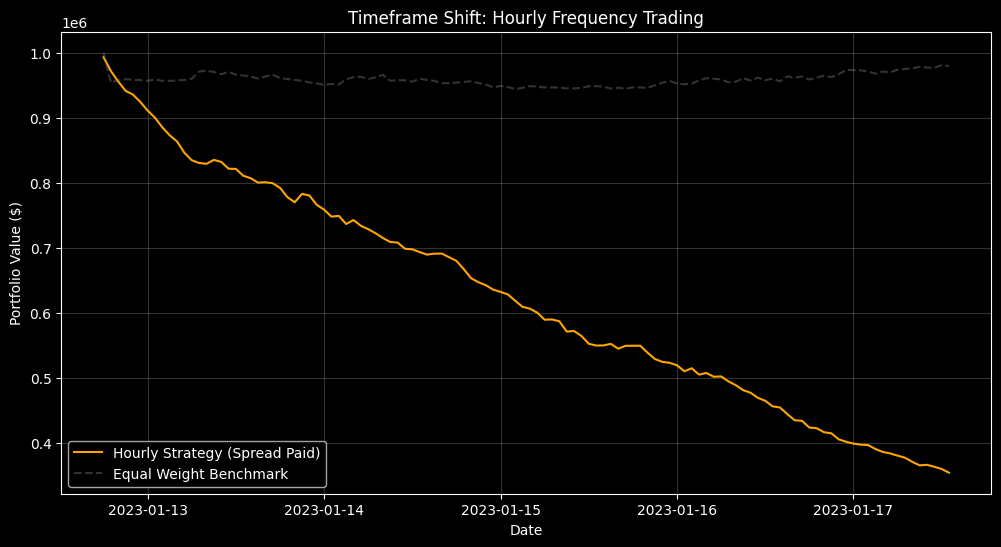

--- Hourly Strategy Metrics ---
Total Return:       -64.27%
Annualized Vol:     32.63%
Sharpe Ratio:       -44.19


In [30]:
print("Resampling data to 1-Hour intervals...")

# 1. Resample the 1-minute data to 1-Hour bars
agg_dict = {
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}

hourly_data = []
for asset, group in df.groupby('Asset'):
    resampled = group.resample('60T').agg(agg_dict).dropna()
    resampled['Asset'] = asset
    hourly_data.append(resampled)

df_hourly = pd.concat(hourly_data).sort_index()

# 2. Engineer Lower-Frequency Features
def engineer_hourly_features(df_h):
    features = pd.DataFrame(index=df_h.index)
    grouped = df_h.groupby('Asset')

    # Macroscopic Momentum & Volatility
    features['Return_1H'] = grouped['Close'].pct_change(1)
    features['Return_3H'] = grouped['Close'].pct_change(3)
    features['Vol_3H'] = grouped['Close'].pct_change(1).transform(lambda x: x.rolling(3).std())

    # Target: Forward 1-Hour Return
    features['Target_1H_Fwd'] = grouped['Close'].transform(lambda x: x.pct_change(1).shift(-1))

    # Spread cost assumption for lower frequency (using a conservative 50 bps spread)
    features['Spread_Cost'] = df_h['Close'] * 0.005

    return pd.concat([df_h, features], axis=1).dropna()

df_hourly_features = engineer_hourly_features(df_hourly)

# 3. Retrain LightGBM on Hourly Data
split_idx_h = int(len(df_hourly_features) * 0.7)
train_data_h = df_hourly_features.iloc[:split_idx_h]
test_data_h = df_hourly_features.iloc[split_idx_h:]

features_cols_h = ['Return_1H', 'Return_3H', 'Vol_3H']

print("Training LightGBM on 1-Hour Features...")
lgb_train_h = lgb.Dataset(train_data_h[features_cols_h], label=train_data_h['Target_1H_Fwd'])
model_h = lgb.train({'objective': 'regression', 'verbose': -1, 'learning_rate': 0.01}, lgb_train_h, num_boost_round=50)

# Rank predictions
test_data_h['Alpha_Score'] = model_h.predict(test_data_h[features_cols_h])
test_data_h['Rank'] = test_data_h.groupby(test_data_h.index)['Alpha_Score'].rank(pct=True)

# 4. Hourly Execution Backtest
def backtest_hourly_strategy(data, initial_capital=1000000, base_bps_cost=10):
    portfolio_value = initial_capital
    cash = initial_capital
    positions = {asset: 0 for asset in data['Asset'].unique()}
    history = []

    grouped_time = data.groupby(data.index)

    for timestamp, current_market in grouped_time:
        # Long top 30%, Short bottom 30%
        longs = current_market[current_market['Rank'] >= 0.7]
        shorts = current_market[current_market['Rank'] <= 0.3]

        target_positions = {}
        long_alloc = (portfolio_value * 1.0) / len(longs) if len(longs) > 0 else 0
        short_alloc = -(portfolio_value * 1.0) / len(shorts) if len(shorts) > 0 else 0

        for _, row in longs.iterrows(): target_positions[row['Asset']] = long_alloc / row['Close']
        for _, row in shorts.iterrows(): target_positions[row['Asset']] = short_alloc / row['Close']

        for asset in positions.keys():
            target_shares = target_positions.get(asset, 0)
            shares_to_trade = target_shares - positions[asset]

            if shares_to_trade != 0:
                asset_data = current_market[current_market['Asset'] == asset]
                if not asset_data.empty:
                    asset_data = asset_data.iloc[0]

                    # Apply the 50 bps spread penalty and 10 bps exchange fee
                    spread_cost = asset_data['Spread_Cost']
                    exec_price = asset_data['Close'] + (np.sign(shares_to_trade) * (spread_cost / 2))

                    trade_value = abs(shares_to_trade) * exec_price
                    commission = trade_value * (base_bps_cost / 10000)

                    cash -= (shares_to_trade * exec_price) + commission
                    positions[asset] += shares_to_trade

        # Mark to Market
        m2m_value = cash
        for asset, shares in positions.items():
            asset_data = current_market[current_market['Asset'] == asset]
            if not asset_data.empty:
                m2m_value += shares * asset_data.iloc[0]['Close']

        portfolio_value = m2m_value
        history.append({'Datetime': timestamp, 'Portfolio_Value': portfolio_value})

    return pd.DataFrame(history).set_index('Datetime')

print("Running Hourly Backtest...")
hourly_results = backtest_hourly_strategy(test_data_h)
hourly_results['Returns'] = hourly_results['Portfolio_Value'].pct_change().fillna(0)

# Calculate Benchmark for Hourly data
benchmark_h = test_data_h.groupby(test_data_h.index)['Close'].mean().pct_change().fillna(0)
benchmark_cum_h = (1 + benchmark_h).cumprod() * 1000000

# --- Plot Hourly Results ---
plt.figure(figsize=(12, 6))
plt.plot(hourly_results.index, hourly_results['Portfolio_Value'], label='Hourly Strategy (Spread Paid)', color='#FFA500')
plt.plot(benchmark_cum_h.index, benchmark_cum_h, label='Equal Weight Benchmark', color='gray', alpha=0.4, linestyle='--')
plt.title("Timeframe Shift: Hourly Frequency Trading")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# --- Calculate Hourly Metrics ---
HOURS_PER_YEAR = 252 * 6.5 # Approx 6.5 trading hours a day
hourly_total_return = (hourly_results['Portfolio_Value'].iloc[-1] / hourly_results['Portfolio_Value'].iloc[0]) - 1
hourly_vol = hourly_results['Returns'].std() * np.sqrt(HOURS_PER_YEAR)
hourly_sharpe = (hourly_results['Returns'].mean() / hourly_results['Returns'].std()) * np.sqrt(HOURS_PER_YEAR)

print("--- Hourly Strategy Metrics ---")
print(f"Total Return:       {hourly_total_return*100:.2f}%")
print(f"Annualized Vol:     {hourly_vol*100:.2f}%")
print(f"Sharpe Ratio:       {hourly_sharpe:.2f}")